<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab #4: Image Classification and Convolutional Neural Networks</h2>
Semester 1, 2026<br>
</center>

**Due**: 11:59pm on Sunday 22 March, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging. Note that this code will not be run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`). Wrap any additional non-TODO related code (e.g., your own tests) in an `if is_notebook():` conditional to avoid issues with our automated grading scripts.

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

In [1]:
# TODO: Replace with your name and university ID
student_name = "Weiyi Jiang"
student_id = "u8191809"

## Disclosure

Used generative AI tools (OpenAI Codex/ChatGPT) to clarify concepts and to review my draft implementations for Tasks 1-5.
All final code was implemented, checked, and verified by me before submission.
No external code was copied directly from non-course sources.

In [2]:
# The ANU lab machines will have python and the necessary packages already installed. If you're working
# on your own machine you will need to install python with Jupyter notebook and PyTorch:
#  - Documentation for the PyTorch deep learning library is here: https://pytorch.org/. Follow the
#    installation instructions (for the stable release), being sure to install both `pytorch` and
#    `torchvision`. You will not need access to a GPU for this course but having one may increase
#    computation speed.
#  Browse through the user documentation and tutorials for these libraries.

import sys
import getpass

def is_notebook():
    return 'ipykernel' in sys.modules

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

if is_notebook():
    print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
    print("Python Version: {}".format(sys.version))
    print("PyTorch Version: {}".format(torch.__version__))

User: cichlidfish (Weiyi Jiang, u8191809)
Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
PyTorch Version: 2.10.0


In [3]:
device = torch.device("cpu")
random_seed = 3242
torch.manual_seed(random_seed)
np.random.seed(random_seed)

## Task 1: Convolution

Implement basic 1D and 2D convolutions using PyTorch

In [4]:
# --- TASK 1A -------------------------------------------------------------------------------------
# Implement a simple 1D convolution function. 
def conv1d(x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
    """1D convolution. 
    
    Args:
        x (torch.Tensor): Input tensor of shape (N,)
        a (torch.Tensor): Kernel / filter tensor of shape (P,) (P < N)
        
    Returns:
        torch.Tensor: Convolved output tensor of shape (N-P+1,)

    Notes:
    - You don't need to consider padding, stride, dilation or bias
    - You can formulate the problem as a matrix multiplication (see lecture slides), though it is not required. 
    """
    #TODO: calculate and return the convolved output y
    
    y = torch.stack([torch.dot(x[i:i+a.numel()], a) for i in range(x.numel()-a.numel()+1)])

    return y


In [5]:
# a simple test 
if is_notebook():
    x = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
    print(f'x: {x}')
    a = torch.tensor([2.0, 0.0, -1.0])
    print(f'a: {a}')
    y= conv1d(x, a)
    print(f'y: {y}')
    expected_y = torch.tensor([-1.0, 0.0, 1.0])
    assert torch.allclose(y, expected_y), "Task 1A failed"
    print("Task 1A passed")

x: tensor([1., 2., 3., 4., 5.])
a: tensor([ 2.,  0., -1.])
y: tensor([-1.,  0.,  1.])
Task 1A passed


In [6]:
# --- TASK 1B -------------------------------------------------------------------------------------
# Implement a 2D convolution with multiple input channels


def conv2d(X: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
    """2D convolution with multiple input channels and a single kernel (refer to lecture slides)
    
    Args:
        X (torch.Tensor): Input tensor of shape (d_channel,n,m,)
        A (torch.Tensor): Kernel / filter tensor of shape (d_channel,p,q)
        
    Returns:
        torch.Tensor: Convolved output tensor of shape (n-p+1,m-q+1)

    Notes:
        - Channel is the first dimension in both X and A, which is different from the lecture slides
        - You don't need to consider padding, stride, dilation or bias
        - The kernel and the input are both 3D, but the function itself is called conv2d following PyTorch conventions
        - You can use for loops. If you want to make your implementation more efficient, check out torch.Tensor.unfold

    """
    #TODO: calculate and return the convolved output Y

    # sum over channels, then slide 2D window
    C, n, m = X.shape
    _, p, q = A.shape
    out_h = n - p + 1
    out_w = m - q + 1
    Y2 = torch.empty((out_h, out_w), dtype=X.dtype)
    for i in range(out_h):
        for j in range(out_w):
            patch = X[:, i:i+p, j:j+q]
            Y2[i, j] = torch.sum(patch * A)
    Y = Y2.unsqueeze(0)
    return Y


In [7]:
if is_notebook():
    X = torch.arange(27, dtype=torch.float32).reshape((3,3,3))
    print(f'X: {X}')
    A = torch.ones((3,2,2))
    print(f'A: {A}')
    Y = conv2d(X, A)
    print(f'Y: {Y}')
    expected_Y = torch.tensor([[[132.0, 144.0], [168.0, 180.0]]])
    assert torch.allclose(Y, expected_Y), "Task 1B failed"
    print("Task 1B passed!")


X: tensor([[[ 0.,  1.,  2.],
         [ 3.,  4.,  5.],
         [ 6.,  7.,  8.]],

        [[ 9., 10., 11.],
         [12., 13., 14.],
         [15., 16., 17.]],

        [[18., 19., 20.],
         [21., 22., 23.],
         [24., 25., 26.]]])
A: tensor([[[1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.]]])
Y: tensor([[[132., 144.],
         [168., 180.]]])
Task 1B passed!


## Task 2: Pooling 



In [8]:
# --- TASK 2 ------------------------------------------------------------------------------------
# Implement a typical 2D channel-wise max pooling, where the stride is the same as the window size.

def maxpool2d(X: torch.Tensor, window_size: int) -> torch.Tensor:
    """Performs channel-wise 2D max pooling
    
    Args:
        X (torch.Tensor): Input array of shape (C, H, W).
        window_size (int): Size of the square pooling window
        
    Returns:
        torch.Tensor: Pooled output of shape (C, H//window_size, W//window_size)

    Notes:
        Read the torch API to learn the difference between torch.max and torch.amax
        Once again, you can use for loops, but torch.Tensor.unfold might make your implementation more efficient
    """
    #TODO: calculate the pooled output 
    C, H, W = X.shape
    w = window_size
    out_h = H // w
    out_w = W // w
    output = torch.empty((C, out_h, out_w), dtype=X.dtype)
    for c in range(C):
        for i in range(out_h):
            for j in range(out_w):
                window = X[c, i*w:(i+1)*w, j*w:(j+1)*w]
                output[c, i, j] = torch.amax(window)
    return output

In [9]:
if is_notebook():
    X_pool = torch.arange(1, 33, dtype=torch.float32).reshape(2, 4, 4)
    print(f'input: {X_pool}')

    out_pool = maxpool2d(X_pool, window_size=2)

    print(f'output: {out_pool}')

    expected_pool = torch.tensor([
        [[6.0, 8.0], [14.0, 16.0]],
        [[22.0, 24.0], [30.0, 32.0]]
    ])  

    assert torch.allclose(out_pool, expected_pool), "Task 2 failed"
    print("Task 2 passed!")

input: tensor([[[ 1.,  2.,  3.,  4.],
         [ 5.,  6.,  7.,  8.],
         [ 9., 10., 11., 12.],
         [13., 14., 15., 16.]],

        [[17., 18., 19., 20.],
         [21., 22., 23., 24.],
         [25., 26., 27., 28.],
         [29., 30., 31., 32.]]])
output: tensor([[[ 6.,  8.],
         [14., 16.]],

        [[22., 24.],
         [30., 32.]]])
Task 2 passed!


## Task 3: CIFAR-10 dataset and evaluation metrics for classification 



CIFAR-10 (https://www.cs.toronto.edu/~kriz/cifar.html) is a standard image classification benchmark dataset consisting of 60,000 colour images (32×32 pixels) across 10 classes. It is divided into 50,000 training images and 10,000 test images.

Run the following cell to download the CIFAR-10 dataset using the torchvision package. You will need an internet connection for this. 

100%|██████████| 170M/170M [1:00:22<00:00, 47.1kB/s] 


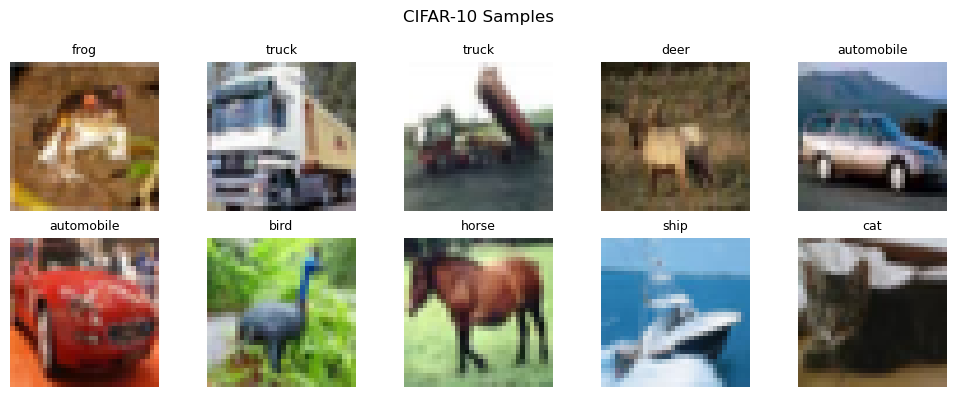

In [10]:
if is_notebook(): 
    CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                    'dog','frog','horse','ship','truck']
    
    def get_cifar10_data():
        transform = transforms.Compose(
            [transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        train_set = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
        test_set  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        return train_set, test_set

    train_data, test_data = get_cifar10_data()

    # Visualise sample images
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        img, label = train_data[i]
        # Undo normalisation for display
        img = img / 2 + 0.5
        ax.imshow(torch.permute(img, (1, 2, 0)))
        ax.set_title(CIFAR10_CLASSES[label], fontsize=9)
        ax.axis('off')
    plt.suptitle('CIFAR-10 Samples')
    plt.tight_layout()
    plt.show()


In [11]:
## --- TASK 3 ------------------------------------------------------------------------------------
# Implement a confusion matrix without calling external libraries 
# you can use torch or numpy 

def calculate_confusion_matrix(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    """Calculates a confusion matrix for a multi-class classification problem.

    A confusion matrix is a (num_classes x num_classes) table that summarises prediction results. 
    Each row corresponds to a true class and each column corresponds to a predicted class. 
    The diagonal line (cm[i, i]) records correct predictions for each class, 
    while off-diagonal entries (cm[i, j], i ≠ j) record misclassifications from ground truth class i to 
    predicted class j. 

    Args:
        y_pred (torch.Tensor): Predictions of shape (N, C) (logits)
        y_true (torch.Tensor): Ground truth labels of shape (N,) of dtype torch.long / torch.int64

        
    Returns:
        torch.Tensor: A confusion matrix of shape (C, C), where cm[i, j] 
        is the count of true class i predicted as class j. The dtype should be torch.long / torch.int64  
    """
    # TODO: Calculate the confusion matrix 
    pred = torch.argmax(y_pred, dim=1)
    num_classes = y_pred.shape[1]
    cm = torch.zeros((num_classes, num_classes), dtype=torch.long)
    for t, p in zip(y_true.tolist(), pred.tolist()):
        cm[t, p] += 1
    return cm


In [12]:
if is_notebook():
    y_pred = torch.tensor([
        [3.1,  -2.2,  0.0],  
        [ -3.6, 3.0,  2.0], 
        [ 1.5, 1.8,  0.2], 
        [ 0.1,  -0.4, 5.2],  
        [1.1,  -1.0,  0.2],  
    ])
    y_true = torch.tensor([0, 0, 1, 2, 2])
    cm = calculate_confusion_matrix(y_pred, y_true)
    print(f"Confusion matrix:\n{cm}")
    assert cm.dtype == torch.long, f"Return dtype is {cm.dtype} instead of {torch.long}"
    expected_cm = torch.tensor([
        [1, 1, 0],
        [0, 1, 0],
        [1, 0, 1]
    ], dtype=torch.long)
    assert torch.equal(cm, expected_cm), "Task 3 failed"
    print("Task 3 passed!")

Confusion matrix:
tensor([[1, 1, 0],
        [0, 1, 0],
        [1, 0, 1]])
Task 3 passed!


## Task 4: CNN for CIFAR-10 classification 

In this task, you will implement a simple CNN for a 10-class classification using the CIFAR-10 dataset. You might want to look at torch.nn (https://docs.pytorch.org/docs/stable/nn.html) to familiarise yourself with different layers available from PyTorch. 

In [13]:
# In pytorch, you can build a model by subclassing nn.Module, 
# which requires you to write an init function that registers the layers, 
# and a forward function to perform the forward pass. 
# The backward pass is automatically handled by PyTorch using automatic differentiation.

## --- TASK 4A ------------------------------------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()


        # TODO: Define the following layers:
        # 1. Conv2d: in channels 3, out channels  12 , kernel 4x4, zero padding of 2 on all sides 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=4, padding=2)
        # 2. MaxPool2d: kernel 2x2
        self.pool  = nn.MaxPool2d(kernel_size=2)
        # 3. Conv2d: in channels 12, out channels 24 , kernel 4x4, zero padding of 2 on all sides
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=4, padding=2)
        # 4. Linear: in features 24*8*8, out features 256
        self.fc1 = nn.Linear(24*8*8, 256)
        # 5. Linear: -> in features 256, out features 10 
        self.fc2 = nn.Linear(256, 10)
        # 6. ReLu: 
        self.relu = nn.ReLU()


    def forward(self, x):
        # TODO: Complete the forward pass: 
        # in shape: (B, 3, 32, 32) 3 channels, 32x32 
        # 1. first conv:  in -> conv1 -> relu -> max pool -> out shape (B, 12, 16, 16)
        # hint: you can stack layers like this: x = layer3(layer2(layer1(x)))
        x = self.pool(self.relu(self.conv1(x)))
        # 2. second conv: in -> conv2 -> relu -> max pool -> out shape (B, 24, 8, 8)
        x = self.pool(self.relu(self.conv2(x)))
        # 3. flatten all dims except the batch dim -> out shape (B, 24*8*8)
        x = torch.flatten(x, start_dim = 1) 
        # 4. final classification head: in -> fc1 -> relu -> fc2 -> out shape (B, 10)
        x = self.fc2(self.relu(self.fc1(x)))
        return x

In [14]:

## --- TASK 4B ------------------------------------------------------------------------------------
# Complete the training function 
def train_model( model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer,
    criterion: nn.Module, epochs: int = 10, device: torch.device = device, 
    val_loader: DataLoader | None = None) -> tuple[list[float], list[float]]:
    """
    Trains a network using mini-batch stochastic gradient descent.

    Args:
        model (nn.Module): The network to train
        loader (DataLoader): Provides mini-batches of (data, target) pairs
        optimizer (torch.optim.Optimizer): Optimizer used to update model parameters
        criterion (callable): Loss function that takes (predictions, targets) and
            returns a scalar loss (we will be using nn.CrossEntropyLoss())
        epochs (int): Number of full passes over the training data
        device (torch.device): Device to train on (CPU or GPU)
        val_loader (DataLoader | None): Optional validation DataLoader. If provided,
            validation loss is computed at the end of each epoch 

    Returns:
        tuple[list[float], list[float]]: A tuple (train_losses, val_losses) of mean 
        training and validation losses per epoch. If no val_loader is provided, 
        val_losses will be empty. 
    """
    
    train_losses = []
    val_losses = []


    for epoch in range(epochs):
        model.train() # set to training mode
        train_loss = 0.0
       
        for data, target in loader:

            data, target = data.to(device), target.to(device) # move data to device 
            # TODO: Implement the training loop. Refer to lab 2 utils if you are not sure what to do 
            # 1. clear accumulated gradient 
            optimizer.zero_grad()
            # 2. forward pass         
            out  = model(data)
            # 3. compute loss 
            loss = criterion(out, target)
            train_loss += loss.item()
            # 4. backward pass to compute gradients  
            loss.backward()
            # 5. update parameters
            optimizer.step()
            # 5. update weights according to the gradients 

        train_losses.append( train_loss/ len(loader))
        
        # validation 
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for data, target in val_loader:
                    data, target = data.to(device), target.to(device)
                    val_loss += criterion(model(data), target).item()
            val_losses.append(val_loss / len(val_loader))
            print(f'Epoch [{epoch+1}/{epochs}] - Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')
    return train_losses, val_losses



In [15]:
## --- TASK 4C ------------------------------------------------------------------------------------
# Create the model, the optimizer and the loss function for training 

# 1. TODO: Create an instance of your SimpleCNN model and move it to the correct compute device
model = SimpleCNN().to(device)
# 2. TODO: Initialise an optimizer and pass the model's parameters to it. 
# Use torch.optim.AdamW , with lr = 1e-3 and weight_decay = 1e-2
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
# 3. TODO: Define the loss function
# Have a look at torch.nn https://docs.pytorch.org/docs/stable/nn.html 
# and find the cross entropy loss. We will be using the default parameters.
criterion = nn.CrossEntropyLoss()


Now, run the following cell to test your implementation.

Epoch [1/10] - Train Loss: 1.8887, Val Loss: 1.7391
Epoch [2/10] - Train Loss: 1.5346, Val Loss: 1.6294
Epoch [3/10] - Train Loss: 1.3579, Val Loss: 1.5086
Epoch [4/10] - Train Loss: 1.2254, Val Loss: 1.4304
Epoch [5/10] - Train Loss: 1.0976, Val Loss: 1.4337
Epoch [6/10] - Train Loss: 0.9807, Val Loss: 1.4667
Epoch [7/10] - Train Loss: 0.8428, Val Loss: 1.4967
Epoch [8/10] - Train Loss: 0.7297, Val Loss: 1.4630
Epoch [9/10] - Train Loss: 0.5766, Val Loss: 1.6178
Epoch [10/10] - Train Loss: 0.4340, Val Loss: 1.7497


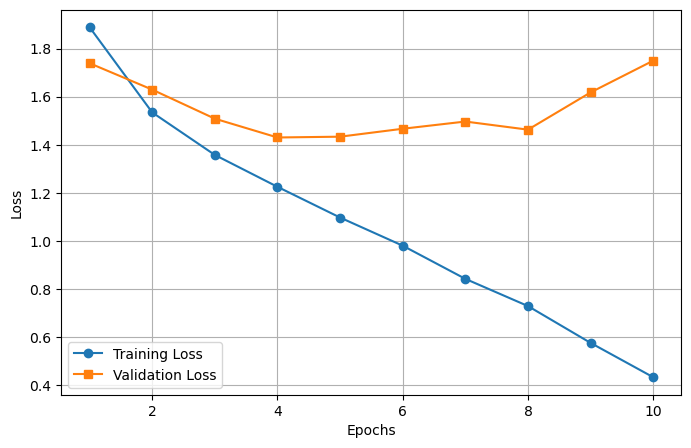


Final Test Accuracy: 0.523
Confusion Matrix:


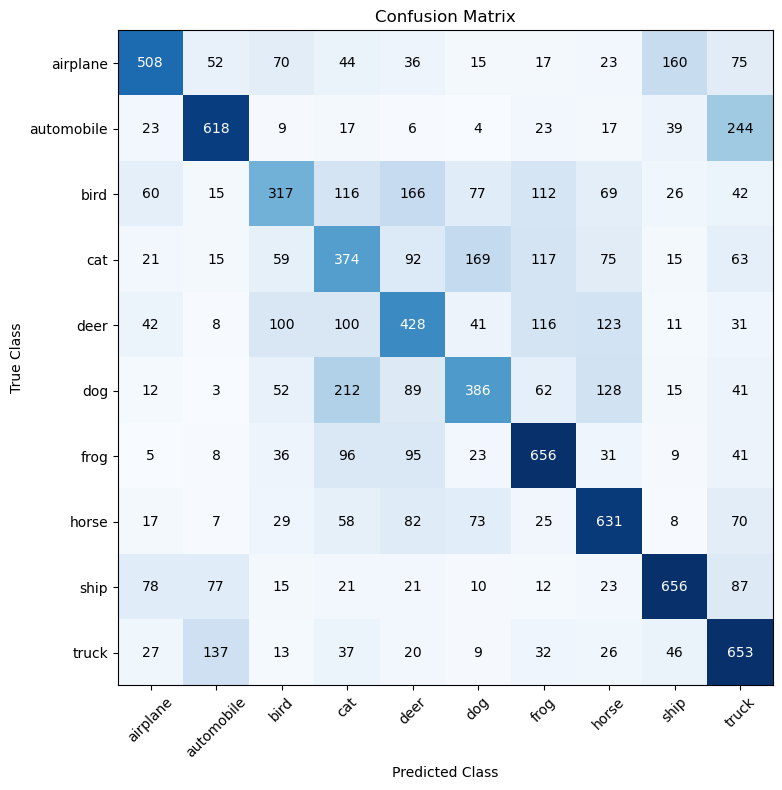

In [16]:
if is_notebook():
    # 1. Prepare train-val-test split 
    g = torch.Generator().manual_seed(3242)
    indices = torch.randperm(len(train_data), generator = g)
    train_indices = indices[:5000]
    val_indices = indices[-500:]
    
    train_sub = Subset(train_data, train_indices)
    val_sub = Subset(train_data, val_indices)
    
    train_loader = DataLoader(train_sub, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_sub, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=500, shuffle=False)
    
    # 2. Training
    epochs = 10 
    train_losses, val_losses = train_model(model, train_loader, optimizer, criterion, 
        epochs=epochs, val_loader=val_loader)
    
    # 3. Plot learning curve 
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss', marker='o')
    plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='s')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 4. Evaluation on the test set
    model.eval()
    all_preds, all_targs = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            out = model(x)
            all_preds.append(out.cpu())
            all_targs.append(y)
            
    cm = calculate_confusion_matrix(torch.cat(all_preds), torch.cat(all_targs))
    print(f"\nFinal Test Accuracy: {torch.diagonal(cm).sum() / cm.sum():.3f}")
    print("Confusion Matrix:")
    # plotting the confusion matrix 
    plt.figure(figsize=(10, 8))
    plt.imshow(cm.numpy(), interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    tick_marks = np.arange(len(CIFAR10_CLASSES))
    plt.xticks(tick_marks, CIFAR10_CLASSES, rotation=45)
    plt.yticks(tick_marks, CIFAR10_CLASSES)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]),ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()

## (Not Marked) (Optional) Task 5: More on image classification 
Now that you have a working pipeline, we encourage you to experiment on model architecture and optimisation settings to see how high you can push your accuracy on the CIFAR-10 dataset.

**Warning: Do not modify code in previous tasks. The autograding script relies on those specific implementations. To experiment on model architecture, copy the relevant code into new cells at the bottom of the notebook, and delete them upon submission**

Suggestions:

- Data: Try using all of CIFAR-10 training data (50,000 images) for training-validation
- Optimisation: Different optimisers, learning rate schedules, batch sizes and regularisation 
- Model complexity: Try adding more convolution layers or increasing the number of channels 
- Early Stopping 
- ...


